{'S': 1.3645748562879805, 'A': 1.7333125028336749, 'B': 0.9375161846676858, 'C': 1.8875900188928383, 'D': 2.238303666641884, 'E': 1.08997960869512, 'F': 0.3014601383327215, 'H': 1.2494076342894638, 'I': 0.39278660646735186, 'G': 0.0}
Path from S to G found: S -> B -> F -> G


{('S', 'A'): Text(0.4112518758642475, 0.3375367241963757, '3'),
 ('S', 'B'): Text(0.008185533639943371, 0.12886465848924536, '2'),
 ('A', 'C'): Text(0.7203780636853272, 0.4071524468539975, '4'),
 ('A', 'D'): Text(0.7486671043044507, 0.6264895077879481, '1'),
 ('B', 'E'): Text(-0.36569669257643445, 0.12123625481265782, '3'),
 ('B', 'F'): Text(-0.2791143566755285, -0.32423362755271445, '1'),
 ('E', 'H'): Text(-0.6190209167474771, 0.3084745726139949, '5'),
 ('F', 'I'): Text(-0.2757546608549866, -0.8292342834431363, '2'),
 ('F', 'G'): Text(-0.4585031384784822, -0.7573084641476335, '3')}

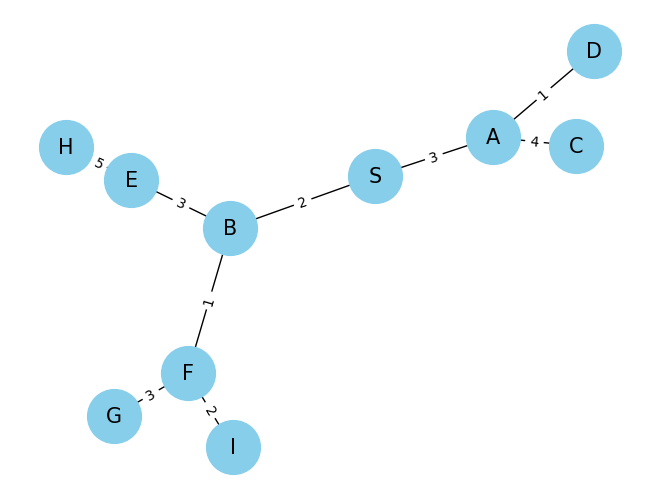

In [1]:
import networkx as nx
import math
import queue

def euclidean_distance(node1, node2, pos):
    x1, y1 = pos[node1]
    x2, y2 = pos[node2]
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def best_first_search(graph, start, goal, heuristic):
    visited = set()
    pri_queue = queue.PriorityQueue()  # Priority queue
    pri_queue.put((heuristic[start], [start]))  # Initial state

    while not pri_queue.empty():
        heruistic_current, current_path = pri_queue.get()
        current_node = current_path[-1]

        if current_node == goal:
            return current_path  # Goal found

        visited.add(current_node)

        for neighbor in graph.neighbors(current_node):
            if neighbor not in visited:
                new_path = current_path + [neighbor]
                pri_queue.put((heuristic[neighbor], new_path))

    return []  # Goal not found


# Example graph
G = nx.Graph()
G.add_weighted_edges_from([('S', 'A', 3), ('S', 'B', 2), ('A', 'C', 4), ('A', 'D', 1), ('B', 'E', 3),('B', 'F', 1),('E', 'H', 5), ('F', 'I', 2), ('F', 'G', 3)])

start_node = 'S'
goal_node = 'G'

# Define positions for the nodes (for Euclidean distance calculation)
pos = nx.spring_layout(G)

# Heuristic function using Euclidean distance
heuristic = {node: euclidean_distance(node, goal_node, pos) for node in G.nodes}

print(heuristic)
path = best_first_search(G, start_node, goal_node, heuristic)
if path:
    print("Path from {} to {} found: {}".format(start_node, goal_node, ' -> '.join(path)))
else:
    print("No path found from {} to {}".format(start_node, goal_node))



nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1500, edge_color='k', linewidths=1, font_size=15)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)


In [2]:
import queue

# Create a priority queue
pri_queue = queue.PriorityQueue()

# Put values into the queue
pri_queue.put(3)
pri_queue.put(1)
pri_queue.put(4)
pri_queue.put(2)

# Display all values without deleting them
print("Priority Queue Elements:", list(pri_queue.queue))


Priority Queue Elements: [1, 2, 4, 3]


In [3]:
pri_queue.get()

1